In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Genre Classification Dataset', 'Untitled.ipynb']


In [3]:
import os
print(os.listdir('Genre Classification Dataset'))

['description.txt', 'test_data.txt', 'test_data_solution.txt', 'train_data.txt']


In [4]:
import pandas as pd

train_df = pd.read_csv('Genre Classification Dataset/train_data.txt', sep=':::', engine='python', 
                        header=None, names=['ID', 'Title', 'Genre', 'Description'])

test_df = pd.read_csv('Genre Classification Dataset/test_data.txt', sep=':::', engine='python', 
                       header=None, names=['ID', 'Title', 'Description'])

print(train_df.head())
print(train_df['Genre'].value_counts())

   ID                               Title       Genre  \
0   1       Oscar et la dame rose (2009)       drama    
1   2                       Cupid (1997)    thriller    
2   3   Young, Wild and Wonderful (1980)       adult    
3   4              The Secret Sin (1915)       drama    
4   5             The Unrecovered (2007)       drama    

                                         Description  
0   Listening in to a conversation between his do...  
1   A brother and sister with a past incestuous r...  
2   As the bus empties the students for their fie...  
3   To help their unemployed father make ends mee...  
4   The film's title refers not only to the un-re...  
Genre
drama           13613
documentary     13096
comedy           7447
short            5073
horror           2204
thriller         1591
action           1315
western          1032
reality-tv        884
family            784
adventure         775
music             731
romance           672
sci-fi            647
adult        

In [5]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_description'] = train_df['Description'].apply(clean_text)
test_df['clean_description'] = test_df['Description'].apply(clean_text)

print(train_df[['Description', 'clean_description']].head())

                                         Description  \
0   Listening in to a conversation between his do...   
1   A brother and sister with a past incestuous r...   
2   As the bus empties the students for their fie...   
3   To help their unemployed father make ends mee...   
4   The film's title refers not only to the un-re...   

                                   clean_description  
0  listening in to a conversation between his doc...  
1  a brother and sister with a past incestuous re...  
2  as the bus empties the students for their fiel...  
3  to help their unemployed father make ends meet...  
4  the films title refers not only to the unrecov...  


In [6]:
from sklearn.model_selection import train_test_split

X = train_df['clean_description']
y = train_df['Genre']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)

(43371,) (10843,)


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print(X_train_tfidf.shape, X_val_tfidf.shape)

(43371, 5000) (10843, 5000)


In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': LinearSVC()
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_val_tfidf)
    acc = accuracy_score(y_val, preds)
    print(f"\n{name} Accuracy: {acc:.4f}")


Naive Bayes Accuracy: 0.5211

Logistic Regression Accuracy: 0.5757

SVM Accuracy: 0.5653


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print(X_train_tfidf.shape, X_val_tfidf.shape)

(43371, 10000) (10843, 10000)


In [10]:
train_df['combined_text'] = train_df['Title'] + ' ' + train_df['Description']
test_df['combined_text'] = test_df['Title'] + ' ' + test_df['Description']

train_df['clean_combined'] = train_df['combined_text'].apply(clean_text)

X = train_df['clean_combined']
y = train_df['Genre']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = LinearSVC(class_weight='balanced', max_iter=2000)
model.fit(X_train_tfidf, y_train)
preds = model.predict(X_val_tfidf)
print(accuracy_score(y_val, preds))

0.513234344738541


In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=3, n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

print("Best C:", grid.best_params_)
print("Best accuracy:", grid.best_score_)

best_model = grid.best_estimator_
preds = best_model.predict(X_val_tfidf)
print("Validation Accuracy:", accuracy_score(y_val, preds))

Best C: {'C': 1}
Best accuracy: 0.5693896843512946
Validation Accuracy: 0.5798210827261828


In [13]:
# Combine title + description for richer text signal
train_df['combined_text'] = train_df['Title'] + ' ' + train_df['Description']
train_df['clean_combined'] = train_df['combined_text'].apply(clean_text)

X = train_df['clean_combined']
y = train_df['Genre']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Better TF-IDF: more features + bigrams
tfidf = TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print(X_train_tfidf.shape, X_val_tfidf.shape)

# Train Logistic Regression with the improved features
best_model = LogisticRegression(max_iter=1000, C=1)
best_model.fit(X_train_tfidf, y_train)
preds = best_model.predict(X_val_tfidf)
print("Validation Accuracy:", accuracy_score(y_val, preds))

(43371, 20000) (10843, 20000)
Validation Accuracy: 0.5857235082541732


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


               precision    recall  f1-score   support

      action        0.58      0.22      0.31       263
       adult        0.72      0.19      0.30       112
   adventure        0.45      0.12      0.19       139
   animation        0.40      0.02      0.04       104
   biography        0.00      0.00      0.00        61
      comedy        0.52      0.60      0.56      1443
       crime        0.33      0.02      0.04       107
 documentary        0.66      0.86      0.75      2659
       drama        0.54      0.80      0.64      2697
      family        0.50      0.07      0.12       150
     fantasy        0.00      0.00      0.00        74
   game-show        0.94      0.40      0.56        40
     history        0.00      0.00      0.00        45
      horror        0.68      0.59      0.63       431
       music        0.65      0.44      0.53       144
     musical        1.00      0.02      0.04        50
     mystery        0.00      0.00      0.00        56
        n

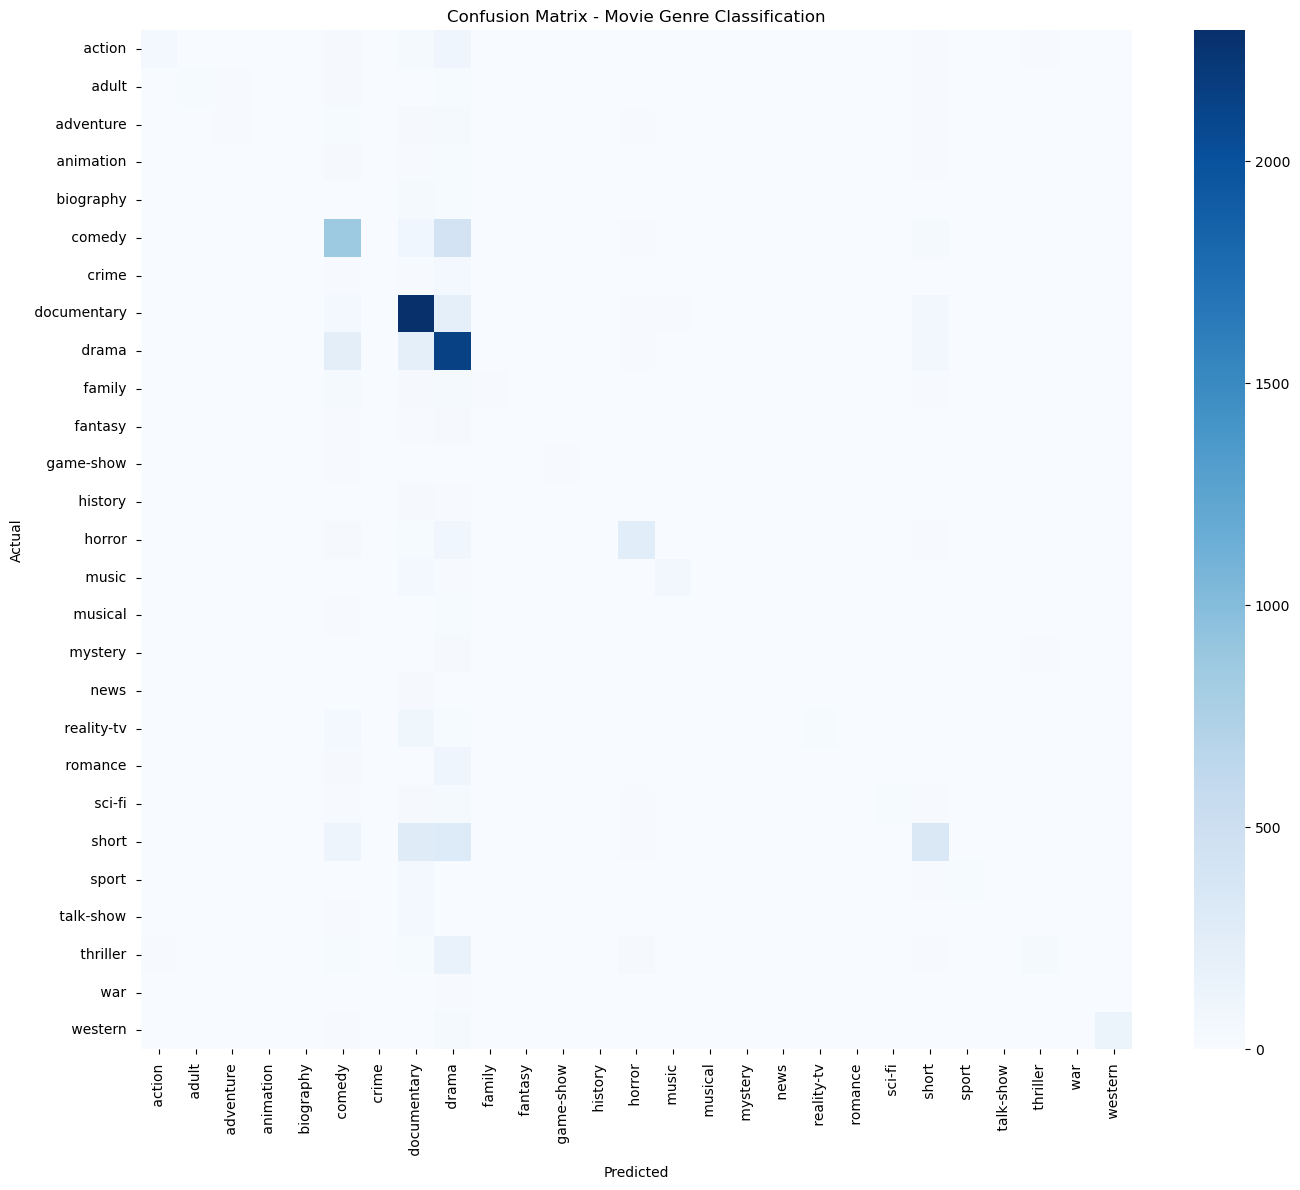

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(classification_report(y_val, preds))

cm = confusion_matrix(y_val, preds, labels=best_model.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', 
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Movie Genre Classification')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [15]:
sample_plots = [
    "A young wizard discovers he has magical powers and attends a school of magic.",
    "Two detectives investigate a series of brutal murders in a small town."
]

samples_clean = [clean_text(s) for s in sample_plots]
samples_tfidf = tfidf.transform(samples_clean)
predictions = best_model.predict(samples_tfidf)
print(predictions)

[' fantasy ' ' horror ']
